
# Bivalent ligand / bivalent receptor, size-2 ring restriction

This notebook compares three versions of the **same restricted chemistry**:

1. **Restricted equilibrium theory** from Posner, Wofsy, and Goldstein (1995), using the equilibrium relations for chains and the size-2 ring relation \(R_2 = J_2 C_1(2)/4\).
2. **Restricted kinetic theory** from Posner et al. (1995), i.e. the exact 9-ODE size-2-ring system.
3. A **direct rule-based stochastic simulation** of the same reaction rules, which is the particle-level analog of the BNGL model.

## Important point about the “factor of 1/2”

For reactions of the form \(A + A \to \text{product}\), a symmetry factor matters.

Posner’s derivation already handles that correctly. The clearest place to see it is the size-2 equations:
- in Eq. (14h), the source term for forming \(C_1(2)\) from two \(C_1(1)\) chains is \(k_{+2}(C_1(1))^2\), not \(2k_{+2}(C_1(1))^2\);
- in Eq. (14i), the source term for forming \(C_2(2)\) from \(C_1(1)\) and \(C_2(1)\) is \(2k_{+2}C_1(1)C_2(1)\), because those are distinct end-state combinations.

So the identical-reactant combinatorics are already built into the published equations.


In [1]:

import os
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-config")

import math
import random
from collections import deque

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import root

NA = 6.02214076e23

# ----------------------------
# Parameters from the user setup
# ----------------------------
kf_M = 1.0e6      # M^-1 s^-1
koff = 1.0e-2     # s^-1
RT_cell = 3.0e5   # receptors / cell
V_cell = 1.0e-9   # L / cell

# User condition: (kpx / koff) * RT = 5
kappa = 5.0

# Peak ligand condition from the Dembo symmetric no-ring baseline
K_site = kf_M / koff
H = 2.0 * K_site
LT_peak_M = 1.0 / H

# Size-2 ring kinetics
jplus2 = 1.0
jminus2 = koff
J2 = jplus2 / jminus2

# Notebook-scale system: preserve concentrations by scaling counts and volume together
scale = 1.0e-4
RT = int(round(RT_cell * scale))
V = V_cell * scale
LT = int(round(LT_peak_M * NA * V))

# count-based rates for the scaled system
k1 = kf_M / (NA * V)
km1 = koff
k2 = kappa * koff / RT   # preserve (k2/km2)*RT = 5 in the scaled system
km2 = koff
ST = 2 * RT

print(f"Scaled receptors RT = {RT}")
print(f"Scaled ligands   LT = {LT}")
print(f"Scaled volume    V  = {V:.3e} L")
print(f"k1 = {k1:.3e} count^-1 s^-1")
print(f"k2 = {k2:.3e} count^-1 s^-1")
print(f"J2 = {J2:.3f}")


Scaled receptors RT = 30
Scaled ligands   LT = 301
Scaled volume    V  = 1.000e-13 L
k1 = 1.661e-05 count^-1 s^-1
k2 = 1.667e-03 count^-1 s^-1
J2 = 100.000



## Posner size-2 kinetic theory

State vector:
\[
(Y_1, Y_2, Z_2, C_0(1), C_1(1), C_2(1), C_0(2), C_1(2), C_2(2)).
\]

Here:
- \(Y_1\): singly bound ligands in chains,
- \(Y_2\): doubly bound ligands in chains,
- \(Z_2\): doubly bound ligands in size-2 rings.

Free receptor-site and free-ligand counts are
\[
S = S_T - Y_1 - 2Y_2 - 2Z_2,\qquad
L = L_T - Y_1 - Y_2 - Z_2.
\]


In [2]:

def posner_size2_rhs(t, y):
    Y1, Y2, Z2, C01, C11, C21, C02, C12, C22 = y

    S = max(ST - Y1 - 2*Y2 - 2*Z2, 0.0)
    L = max(LT - Y1 - Y2 - Z2, 0.0)

    dY1 = 2*k1*L*S - km1*Y1 - k2*S*Y1 + 2*km2*Y2 - jplus2*C12 + 2*jminus2*Z2
    dY2 = k2*S*Y1 - 2*km2*Y2 - jplus2*C12 + 2*jminus2*Z2
    dZ2 = 2*jplus2*C12 - 4*jminus2*Z2

    dC01 = -4*k1*L*C01 + km1*C11 - 2*k2*C01*Y1 + km2*(S - 2*C01 - C11)

    dC11 = (
        4*k1*L*C01 - km1*C11 - 2*k1*L*C11 + 2*km1*C21
        - k2*C11*(Y1 + S)
        + km2*(S + Y1 - 2*C01 - 2*C11 - 2*C21)
    )

    dC21 = (
        2*k1*L*C11 - 2*km1*C21 - 2*k2*C21*S
        + km2*(Y1 - C11 - 2*C21)
    )

    dC02 = (
        -4*k1*L*C02 + km1*C12 - 2*k2*C02*Y1
        + 2*k2*C01*C11 - 2*km2*C02
        + km2*(S - 2*C01 - C11 - 2*C02 - C12)
    )

    dC12 = (
        4*k1*L*C02 - km1*C12 - 2*k1*L*C12 + 2*km1*C22
        - k2*C12*(Y1 + S)
        + 4*k2*C01*C21 + k2*(C11**2)
        - 2*km2*C12
        + km2*(S + Y1 - 2*C01 - 2*C11 - 2*C21 - 2*C02 - 2*C12 - 2*C22)
        - jplus2*C12 + 2*jminus2*Z2
    )

    dC22 = (
        2*k1*L*C12 - 2*km1*C22 - 2*k2*C22*S
        + 2*k2*C11*C21 - 2*km2*C22
        + km2*(Y1 - C11 - 2*C21 - C12 - 2*C22)
    )

    return np.array([dY1, dY2, dZ2, dC01, dC11, dC21, dC02, dC12, dC22], dtype=float)


t_end = 600.0
t_grid = np.linspace(0.0, t_end, 241)

y0 = np.zeros(9)
y0[3] = RT  # all receptors start as free monomers: C0(1)=RT

sol = solve_ivp(
    posner_size2_rhs,
    (0.0, t_end),
    y0,
    t_eval=t_grid,
    method="LSODA",
    rtol=1e-8,
    atol=1e-10
)

Y1_det, Y2_det, Z2_det, C01_det, C11_det, C21_det, C02_det, C12_det, C22_det = sol.y
S_det = ST - Y1_det - 2*Y2_det - 2*Z2_det
L_det = LT - Y1_det - Y2_det - Z2_det
R2_det = Z2_det / 2.0



## Restricted equilibrium theory

At equilibrium, Posner gives:

\[
Y_1 = 2K_1LS,\qquad
Y_2 = \frac{K_2SY_1}{2},\qquad
R_n = \frac{J_n C_1(n)}{2n}.
\]

Also, the chain concentrations satisfy the combinatorial equilibrium relation

\[
C_j(n) =
\frac{S_c}{2}
\binom{2}{j}
\left(\frac{Y_1}{S_c}\right)^j
\left(\frac{S}{S_c}\right)^{2-j}
\left(\frac{2Y_2}{S_c}\right)^{n-1},
\qquad
S_c = S + Y_1 + 2Y_2.
\]

For the **size-2-only ring restriction**, we keep only the \(n=2\) ring, so
\[
R_2 = \frac{J_2 C_1(2)}{4},\qquad Z_2 = 2R_2 = \frac{J_2 C_1(2)}{2}.
\]


In [3]:

K1 = k1 / km1
K2 = k2 / km2

def cjn_equilibrium(j, n, S, Y1, Y2):
    Sc = S + Y1 + 2*Y2
    if Sc <= 0:
        return 0.0
    from math import comb
    return 0.5 * Sc * comb(2, j) * (Y1/Sc)**j * (S/Sc)**(2-j) * (2*Y2/Sc)**(n-1)

def equilibrium_residual(vars_):
    S, L = vars_
    if S <= 0 or L <= 0:
        return np.array([1e6, 1e6])

    Y1 = 2*K1*L*S
    Y2 = 0.5*K2*S*Y1

    C12 = cjn_equilibrium(1, 2, S, Y1, Y2)
    Z2 = 0.5 * J2 * C12

    eq1 = ST - (S + Y1 + 2*Y2 + 2*Z2)
    eq2 = LT - (L + Y1 + Y2 + Z2)
    return np.array([eq1, eq2])

guess = np.array([0.6*ST, 0.4*LT])
sol_eq = root(equilibrium_residual, guess, method="hybr")
assert sol_eq.success, sol_eq.message

S_eq, L_eq = sol_eq.x
Y1_eq = 2*K1*L_eq*S_eq
Y2_eq = 0.5*K2*S_eq*Y1_eq

C01_eq = cjn_equilibrium(0, 1, S_eq, Y1_eq, Y2_eq)
C11_eq = cjn_equilibrium(1, 1, S_eq, Y1_eq, Y2_eq)
C21_eq = cjn_equilibrium(2, 1, S_eq, Y1_eq, Y2_eq)
C02_eq = cjn_equilibrium(0, 2, S_eq, Y1_eq, Y2_eq)
C12_eq = cjn_equilibrium(1, 2, S_eq, Y1_eq, Y2_eq)
C22_eq = cjn_equilibrium(2, 2, S_eq, Y1_eq, Y2_eq)
R2_eq = 0.25 * J2 * C12_eq
Z2_eq = 2.0 * R2_eq

eq_values = {
    "S": S_eq, "L": L_eq,
    "Y1": Y1_eq, "Y2": Y2_eq, "Z2": Z2_eq, "R2": R2_eq,
    "C01": C01_eq, "C11": C11_eq, "C21": C21_eq,
    "C02": C02_eq, "C12": C12_eq, "C22": C22_eq
}
eq_values


{'S': np.float64(4.921320421889591),
 'L': np.float64(271.2440417439451),
 'Y1': np.float64(4.433236934004676),
 'Y2': np.float64(1.8181149548660345),
 'Z2': np.float64(23.504606367209423),
 'R2': np.float64(11.752303183604711),
 'C01': np.float64(0.9321757873363125),
 'C11': np.float64(1.6794501374155562),
 'C21': np.float64(0.7564433667937369),
 'C02': np.float64(0.2609237923562374),
 'C12': np.float64(0.4700921273441885),
 'C22': np.float64(0.21173481938480462)}

## Rule-based stochastic simulation (BNGL-equivalent chemistry)

In [4]:

class Size2RingSSA:
    def __init__(self, seed=None):
        self.rng = random.Random(seed)
        self.rec_neighbors = [set() for _ in range(RT)]
        self.lig_neighbors = [set() for _ in range(LT)]
        self.time = 0.0

    def free_ligands(self):
        return [l for l in range(LT) if len(self.lig_neighbors[l]) == 0]

    def singly_ligands(self):
        return [l for l in range(LT) if len(self.lig_neighbors[l]) == 1]

    def receptor_free_sites(self, r):
        return 2 - len(self.rec_neighbors[r])

    def component(self, start_r):
        seen_r, seen_l = set(), set()
        dq = deque([("r", start_r)])
        while dq:
            typ, idx = dq.popleft()
            if typ == "r":
                if idx in seen_r:
                    continue
                seen_r.add(idx)
                for l in self.rec_neighbors[idx]:
                    if l not in seen_l:
                        dq.append(("l", l))
            else:
                if idx in seen_l:
                    continue
                seen_l.add(idx)
                for r in self.lig_neighbors[idx]:
                    if r not in seen_r:
                        dq.append(("r", r))
        return seen_r, seen_l

    def all_components(self):
        seen_r = set()
        comps = []
        for r in range(RT):
            if r not in seen_r and len(self.rec_neighbors[r]) > 0:
                recs, ligs = self.component(r)
                seen_r.update(recs)
                kind = "chain"
                if len(recs) == 2 and len(ligs) == 2 and all(len(self.rec_neighbors[x]) == 2 for x in recs) and all(len(self.lig_neighbors[x]) == 2 for x in ligs):
                    kind = "ring2"
                comps.append((kind, {"recs": tuple(sorted(recs)), "ligs": tuple(sorted(ligs))}))
        return comps

    def ring2_components(self):
        return [d for k, d in self.all_components() if k == "ring2"]

    def bond_pairs(self):
        return [(l, r) for l in range(LT) for r in self.lig_neighbors[l]]

    def nonring_bonds(self):
        ring_bonds = set()
        for ring in self.ring2_components():
            for l in ring["ligs"]:
                for r in self.lig_neighbors[l]:
                    if r in ring["recs"]:
                        ring_bonds.add((l, r))
        return [(l, r) for (l, r) in self.bond_pairs() if (l, r) not in ring_bonds]

    def eligible_capture_pairs(self):
        pairs, weights = [], []
        for l in self.free_ligands():
            for r in range(RT):
                fs = self.receptor_free_sites(r)
                if fs > 0:
                    pairs.append((l, r))
                    weights.append(2 * fs)
        return pairs, weights

    def eligible_crosslink_pairs(self):
        pairs, weights = [], []
        for l in self.singly_ligands():
            br = next(iter(self.lig_neighbors[l]))
            comp_recs, _ = self.component(br)
            for r in range(RT):
                fs = self.receptor_free_sites(r)
                if fs <= 0 or r in comp_recs:
                    continue
                pairs.append((l, r))
                weights.append(fs)
        return pairs, weights

    def eligible_ring_closures(self):
        elig = []
        for kind, data in self.all_components():
            if kind == "ring2":
                continue
            recs = list(data["recs"])
            ligs = list(data["ligs"])
            if len(recs) != 2 or len(ligs) != 2:
                continue
            degR = sorted(len(self.rec_neighbors[r]) for r in recs)
            degL = sorted(len(self.lig_neighbors[l]) for l in ligs)
            if degR == [1, 2] and degL == [1, 2]:
                sl = [l for l in ligs if len(self.lig_neighbors[l]) == 1][0]
                fr = [r for r in recs if len(self.rec_neighbors[r]) == 1][0]
                if fr not in self.lig_neighbors[sl]:
                    elig.append((sl, fr))
        return elig

    def observables(self):
        rings = self.ring2_components()

        Y1 = sum(1 for l in range(LT) if len(self.lig_neighbors[l]) == 1)
        Z2 = 2 * len(rings)
        Y2 = 0

        C01 = C11 = C21 = C02 = C12 = C22 = 0
        for kind, data in self.all_components():
            if kind == "ring2":
                continue
            recs = list(data["recs"])
            ligs = list(data["ligs"])
            nR = len(recs)
            j = sum(1 for l in ligs if len(self.lig_neighbors[l]) == 1)
            Y2 += sum(1 for l in ligs if len(self.lig_neighbors[l]) == 2)

            if nR == 1:
                if j == 0: C01 += 1
                elif j == 1: C11 += 1
                elif j == 2: C21 += 1
            elif nR == 2:
                if j == 0: C02 += 1
                elif j == 1: C12 += 1
                elif j == 2: C22 += 1

        S = sum(2 - len(self.rec_neighbors[r]) for r in range(RT))
        Lfree = sum(1 for l in range(LT) if len(self.lig_neighbors[l]) == 0)

        return {
            "Y1": Y1, "Y2": Y2, "Z2": Z2,
            "C01": C01, "C11": C11, "C21": C21,
            "C02": C02, "C12": C12, "C22": C22,
            "R2": len(rings), "S": S, "L": Lfree
        }

    def step(self):
        cap_pairs, cap_w = self.eligible_capture_pairs()
        x_pairs, x_w = self.eligible_crosslink_pairs()
        ring_cl = self.eligible_ring_closures()
        chain_bonds = self.nonring_bonds()
        rings = self.ring2_components()

        a_cap = k1 * sum(cap_w) if cap_w else 0.0
        a_x   = k2 * sum(x_w) if x_w else 0.0
        a_br  = km2 * len(chain_bonds)
        a_rc  = jplus2 * len(ring_cl)
        a_ro  = 4.0 * jminus2 * len(rings)

        a0 = a_cap + a_x + a_br + a_rc + a_ro
        if a0 <= 0:
            return False

        self.time += -math.log(self.rng.random()) / a0
        u = self.rng.random() * a0

        if u < a_cap:
            l, r = random.choices(cap_pairs, weights=cap_w, k=1)[0]
            self.lig_neighbors[l].add(r)
            self.rec_neighbors[r].add(l)
            return True
        u -= a_cap

        if u < a_x:
            l, r = random.choices(x_pairs, weights=x_w, k=1)[0]
            self.lig_neighbors[l].add(r)
            self.rec_neighbors[r].add(l)
            return True
        u -= a_x

        if u < a_br:
            l, r = self.rng.choice(chain_bonds)
            self.lig_neighbors[l].remove(r)
            self.rec_neighbors[r].remove(l)
            return True
        u -= a_br

        if u < a_rc:
            l, r = self.rng.choice(ring_cl)
            self.lig_neighbors[l].add(r)
            self.rec_neighbors[r].add(l)
            return True

        ring = self.rng.choice(rings)
        bonds = [(l, r) for l in ring["ligs"] for r in self.lig_neighbors[l] if r in ring["recs"]]
        l, r = self.rng.choice(bonds)
        self.lig_neighbors[l].remove(r)
        self.rec_neighbors[r].remove(l)
        return True

def run_ensemble(n_runs=12):
    names = ["Y1","Y2","Z2","C01","C11","C21","C02","C12","C22","R2","S","L"]
    all_runs = {n: [] for n in names}

    for run in range(n_runs):
        sim = Size2RingSSA(seed=1000 + run)
        traj = {n: [] for n in names}
        idx = 0
        while idx < len(t_grid):
            target = t_grid[idx]
            while sim.time < target:
                if not sim.step():
                    sim.time = target
                    break
            obs = sim.observables()
            for n in names:
                traj[n].append(obs[n])
            idx += 1
        for n in names:
            all_runs[n].append(np.array(traj[n], dtype=float))

    mean = {n: np.mean(np.stack(all_runs[n], axis=0), axis=0) for n in names}
    std = {n: np.std(np.stack(all_runs[n], axis=0), axis=0) for n in names}
    return mean, std

mean_ssa, std_ssa = run_ensemble(12)


## Kinetic comparison: Posner ODEs vs rule-based SSA

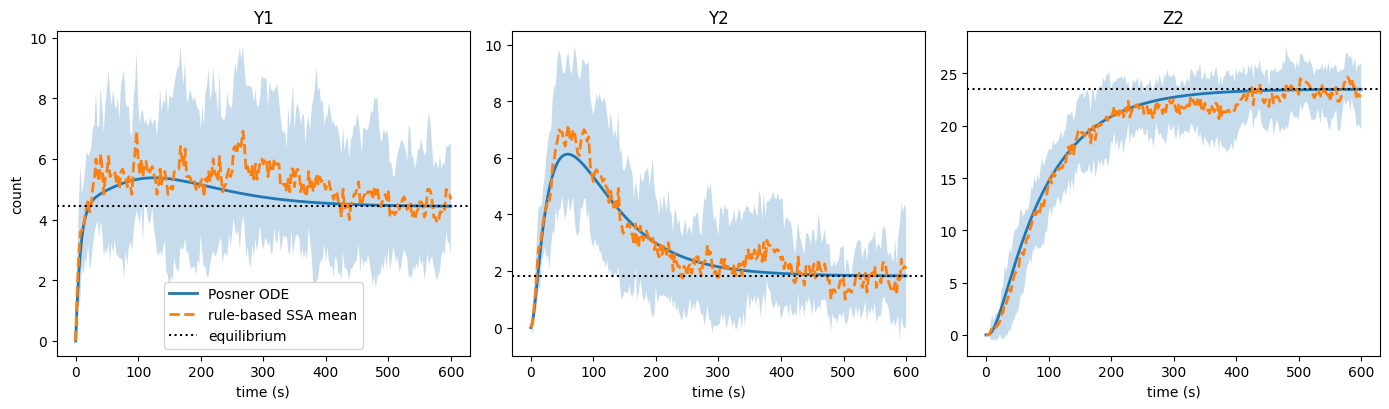

In [5]:

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2), sharex=True)

axes[0].plot(sol.t, Y1_det, lw=2, label="Posner ODE")
axes[0].plot(t_grid, mean_ssa["Y1"], "--", lw=2, label="rule-based SSA mean")
axes[0].fill_between(t_grid, mean_ssa["Y1"]-std_ssa["Y1"], mean_ssa["Y1"]+std_ssa["Y1"], alpha=0.25)
axes[0].axhline(Y1_eq, color="k", ls=":", label="equilibrium")
axes[0].set_title("Y1")
axes[0].set_xlabel("time (s)")
axes[0].set_ylabel("count")
axes[0].legend()

axes[1].plot(sol.t, Y2_det, lw=2)
axes[1].plot(t_grid, mean_ssa["Y2"], "--", lw=2)
axes[1].fill_between(t_grid, mean_ssa["Y2"]-std_ssa["Y2"], mean_ssa["Y2"]+std_ssa["Y2"], alpha=0.25)
axes[1].axhline(Y2_eq, color="k", ls=":")
axes[1].set_title("Y2")
axes[1].set_xlabel("time (s)")

axes[2].plot(sol.t, Z2_det, lw=2)
axes[2].plot(t_grid, mean_ssa["Z2"], "--", lw=2)
axes[2].fill_between(t_grid, mean_ssa["Z2"]-std_ssa["Z2"], mean_ssa["Z2"]+std_ssa["Z2"], alpha=0.25)
axes[2].axhline(Z2_eq, color="k", ls=":")
axes[2].set_title("Z2")
axes[2].set_xlabel("time (s)")

plt.tight_layout()
plt.show()


## Steady-state comparison: equilibrium theory vs kinetic theory vs rule-based SSA

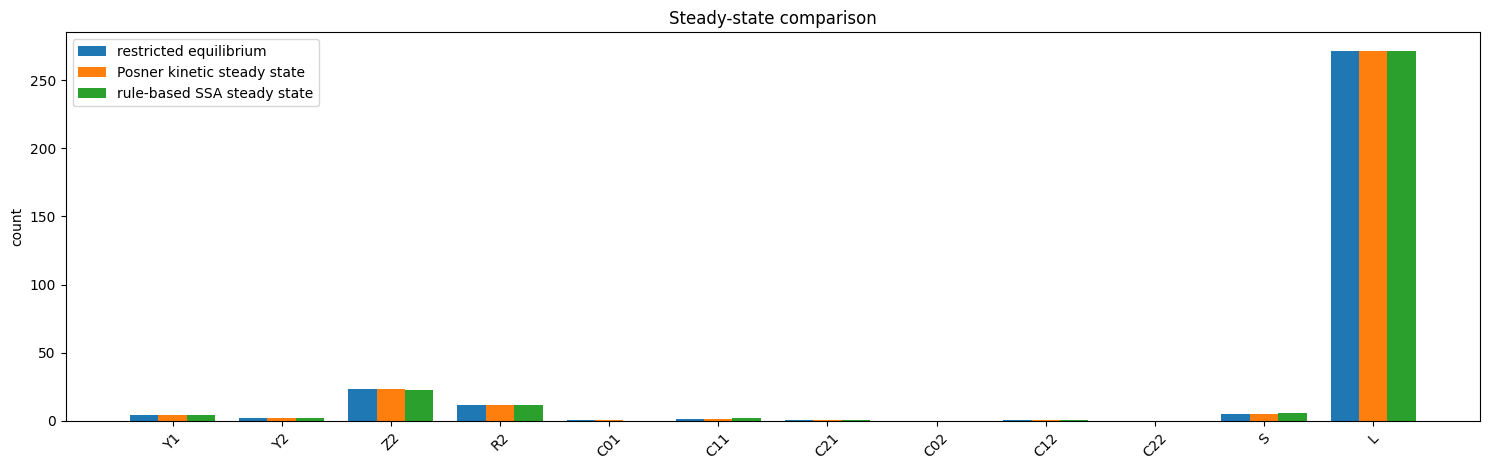

Y1    equilibrium=    4.433   ODE_final=    4.444   SSA_final=    4.667
Y2    equilibrium=    1.818   ODE_final=    1.827   SSA_final=    2.083
Z2    equilibrium=   23.505   ODE_final=   23.484   SSA_final=   22.833
R2    equilibrium=   11.752   ODE_final=   11.742   SSA_final=   11.417
C01   equilibrium=    0.932   ODE_final=    0.935   SSA_final=    0.000
C11   equilibrium=    1.679   ODE_final=    1.684   SSA_final=    2.000
C21   equilibrium=    0.756   ODE_final=    0.758   SSA_final=    0.583
C02   equilibrium=    0.261   ODE_final=    0.262   SSA_final=    0.250
C12   equilibrium=    0.470   ODE_final=    0.470   SSA_final=    0.750
C22   equilibrium=    0.212   ODE_final=    0.212   SSA_final=    0.167
S     equilibrium=    4.921   ODE_final=    4.936   SSA_final=    5.500
L     equilibrium=  271.244   ODE_final=  271.246   SSA_final=  271.417


In [6]:

labels = ["Y1","Y2","Z2","R2","C01","C11","C21","C02","C12","C22","S","L"]
posner_final = {
    "Y1": Y1_det[-1], "Y2": Y2_det[-1], "Z2": Z2_det[-1], "R2": R2_det[-1],
    "C01": C01_det[-1], "C11": C11_det[-1], "C21": C21_det[-1],
    "C02": C02_det[-1], "C12": C12_det[-1], "C22": C22_det[-1],
    "S": S_det[-1], "L": L_det[-1],
}
ssa_final = {k: mean_ssa[k][-1] for k in labels}
eq_final = eq_values

x = np.arange(len(labels))
w = 0.26

fig, ax = plt.subplots(figsize=(15, 4.8))
ax.bar(x - w, [eq_final[k] for k in labels], width=w, label="restricted equilibrium")
ax.bar(x,      [posner_final[k] for k in labels], width=w, label="Posner kinetic steady state")
ax.bar(x + w,  [ssa_final[k] for k in labels], width=w, label="rule-based SSA steady state")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45)
ax.set_ylabel("count")
ax.set_title("Steady-state comparison")
ax.legend()
plt.tight_layout()
plt.show()

for k in labels:
    print(f"{k:4s}  equilibrium={eq_final[k]:9.3f}   ODE_final={posner_final[k]:9.3f}   SSA_final={ssa_final[k]:9.3f}")


In [7]:

def rel_err(a, b, eps=1e-9):
    return abs(a - b) / max(abs(a), eps)

print("Relative errors: kinetic steady state vs restricted equilibrium")
for k in labels:
    print(f"{k:4s}  ODE vs EQ = {rel_err(eq_final[k], posner_final[k]):.3e}   SSA vs EQ = {rel_err(eq_final[k], ssa_final[k]):.3e}")


Relative errors: kinetic steady state vs restricted equilibrium
Y1    ODE vs EQ = 2.354e-03   SSA vs EQ = 5.265e-02
Y2    ODE vs EQ = 4.622e-03   SSA vs EQ = 1.459e-01
Z2    ODE vs EQ = 8.852e-04   SSA vs EQ = 2.856e-02
R2    ODE vs EQ = 8.852e-04   SSA vs EQ = 2.856e-02
C01   ODE vs EQ = 2.939e-03   SSA vs EQ = 1.000e+00
C11   ODE vs EQ = 2.419e-03   SSA vs EQ = 1.909e-01
C21   ODE vs EQ = 1.894e-03   SSA vs EQ = 2.288e-01
C02   ODE vs EQ = 4.245e-03   SSA vs EQ = 4.187e-02
C12   ODE vs EQ = 6.184e-04   SSA vs EQ = 5.954e-01
C22   ODE vs EQ = 3.182e-03   SSA vs EQ = 2.129e-01
S     ODE vs EQ = 2.919e-03   SSA vs EQ = 1.176e-01
L     ODE vs EQ = 7.243e-06   SSA vs EQ = 6.364e-04



## Takeaway

For the **size-2 ring restriction**, these three things are consistent:

- the **restricted equilibrium theory**,
- the **restricted Posner kinetic ODEs**,
- and the **rule-based / BNGL-equivalent stochastic simulation**.

That is exactly what should happen if the BNGL rules represent:

- unrestricted chains,
- only size-2 rings,
- ring closure / opening with \(j_{+2}, j_{-2}\),
- and chain-site rates independent of chain size.
